# Part B: Dataset Understanding & Preparation
**Robust Regression Engine**

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

## Task 6 — Load Dataset & Identify Features and Target Variable

In [2]:
df = pd.read_csv(r"D:\Python_rnw\one\supervised learning\PR2\Advanced_Regression_HousePrice_Dataset_3800 - Advanced_Regression_HousePrice_Dataset_3800.csv.csv")
df.head()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


In [3]:
df.shape

(3800, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   str    
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 356.4 KB


In [5]:
df.describe()

,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
count,3800.00000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3.800000e+03
mean,201900.50000,1716.925526,3.428158,2.916316,6.502237,22.537105,13.085132,0.548421,0.472895,4.242911,2.071940e+07
std,1097.10984,582.996559,1.356682,1.133540,1.766945,12.325740,6.537425,0.497715,0.499330,2.045371,8.707465e+06
min,200001.00000,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.500000,1.506126e+06
25%,200950.75000,1322.000000,2.000000,2.000000,5.300000,14.000000,8.500000,0.000000,0.000000,2.810000,1.446895e+07
50%,201900.50000,1700.500000,3.000000,3.000000,6.500000,20.000000,13.000000,1.000000,0.000000,4.220000,1.989180e+07
75%,202850.25000,2105.000000,4.000000,4.000000,7.700000,29.000000,17.500000,1.000000,1.000000,5.650000,2.596062e+07
max,203800.00000,3776.000000,7.000000,6.000000,10.000000,80.000000,38.700000,1.000000,1.000000,12.000000,5.930315e+07


In [6]:
df.isnull().sum()

property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
cols = list(df.columns)
cols

['property_id',
 'sale_date',
 'area_sqft',
 'bedrooms',
 'bathrooms',
 'location_score',
 'property_age',
 'distance_city_km',
 'near_school',
 'near_metro',
 'crime_rate_index',
 'house_price_inr']

In [9]:
TARGET = 'house_price_inr'
DROP_COLS = ['property_id', 'sale_date']

FEATURES = [col for col in df.columns if col not in [TARGET] + DROP_COLS]

print("Target Variable :", TARGET)
print("Feature Variables :", FEATURES)

Target Variable : house_price_inr
Feature Variables : ['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index']


## EDA — Numerical Columns

In [10]:
num_cols = []

for col in FEATURES:
    if df[col].dtype != 'object':
        num_cols.append(col)

print(num_cols)

['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index']


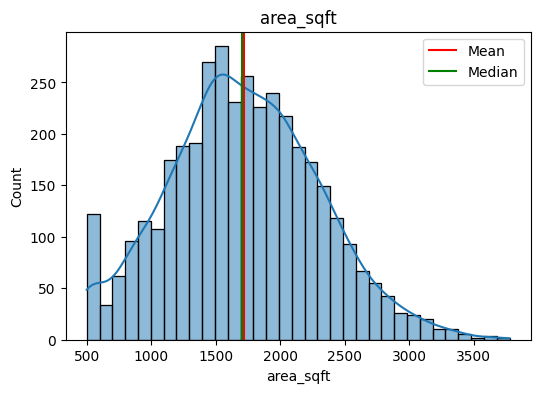

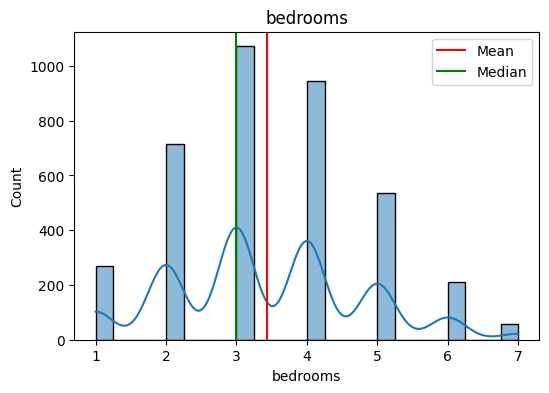

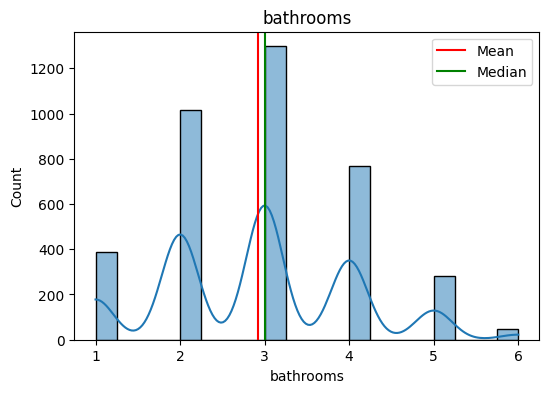

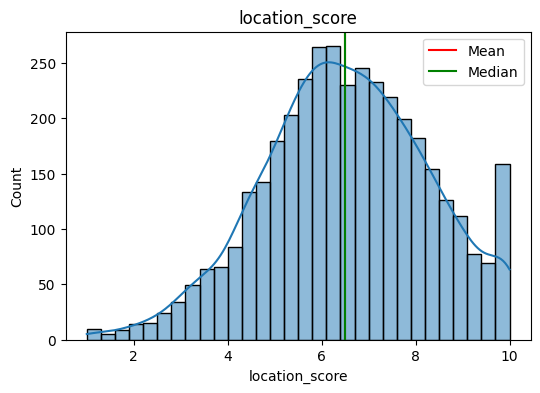

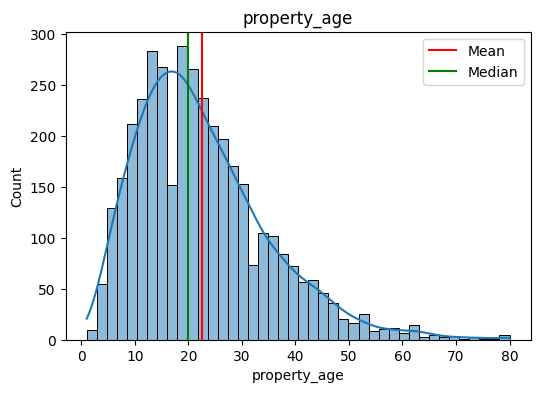

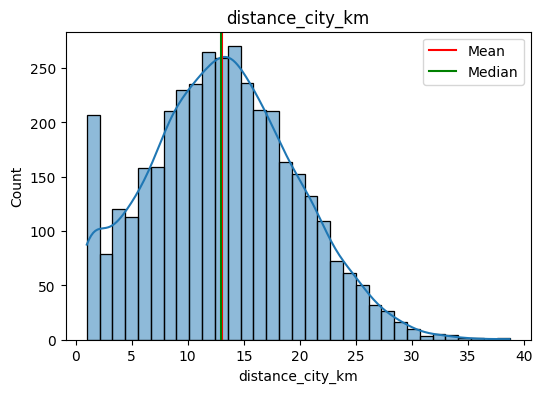

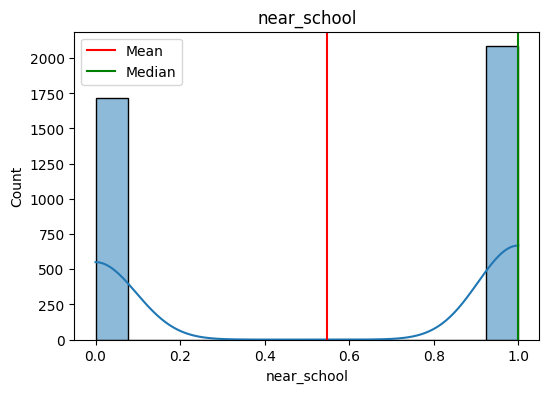

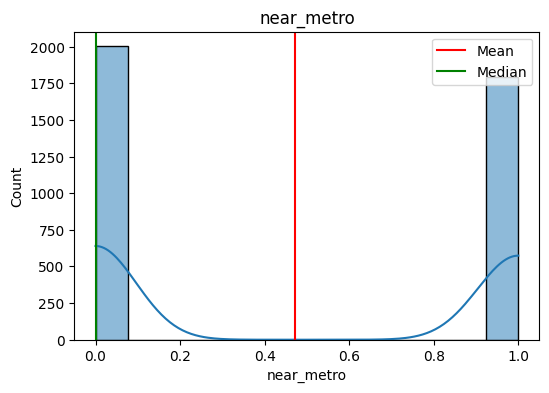

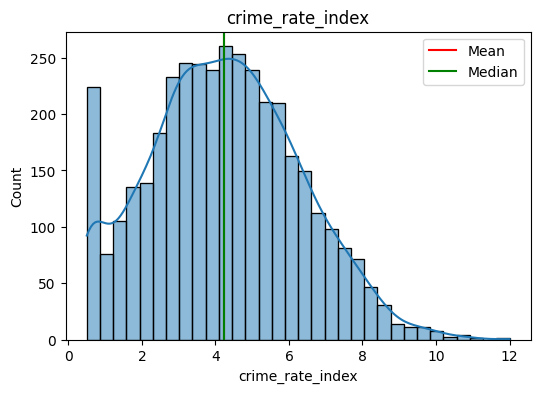

In [11]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.axvline(df[col].mean(), color='red', label='Mean')
    plt.axvline(df[col].median(), color='green', label='Median')
    plt.title(col)
    plt.legend()
    plt.show()

## EDA — Outlier Detection

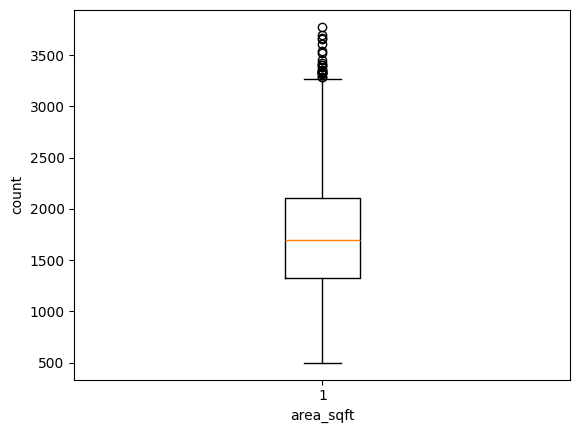

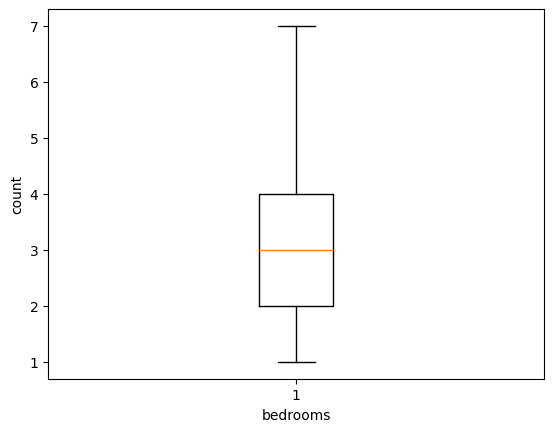

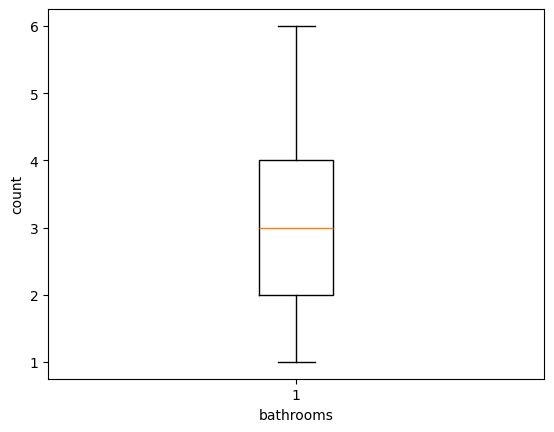

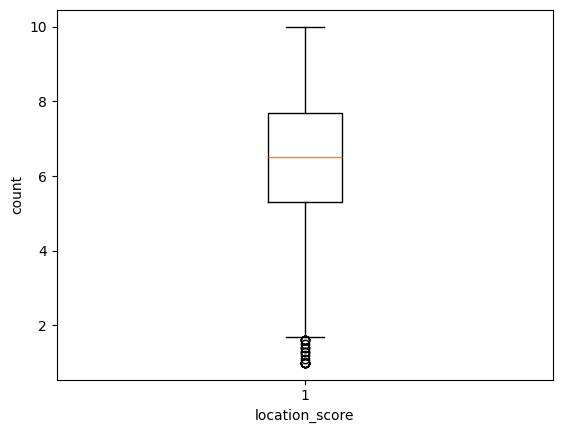

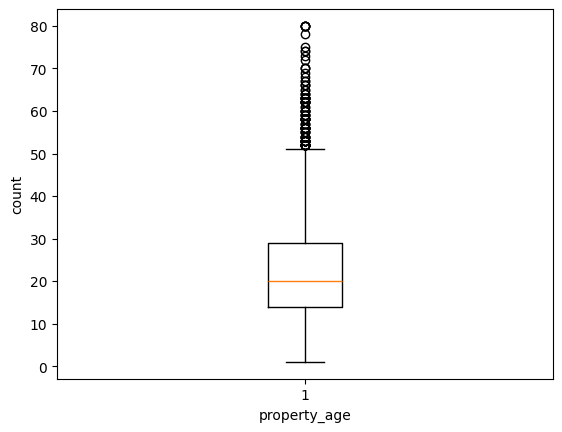

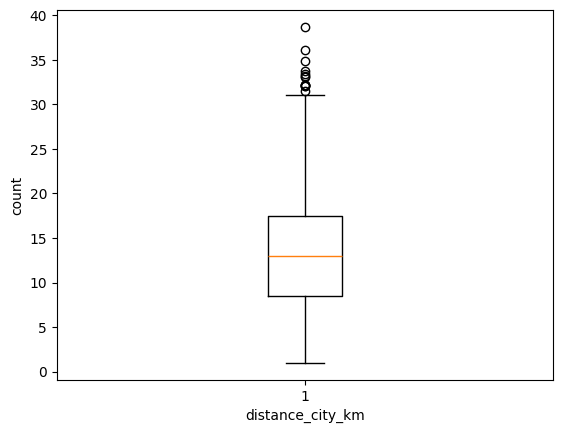

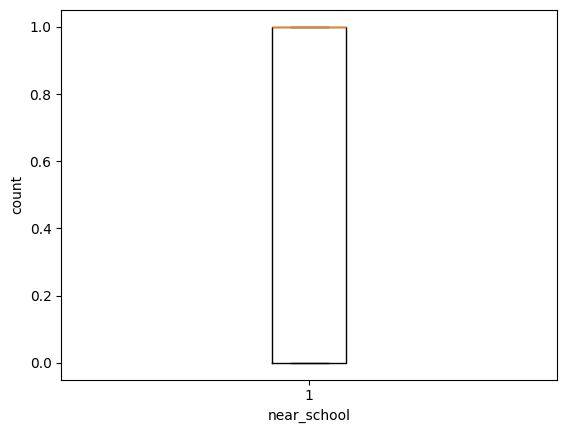

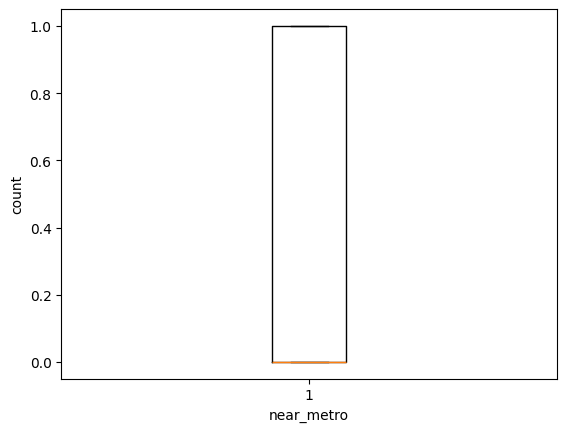

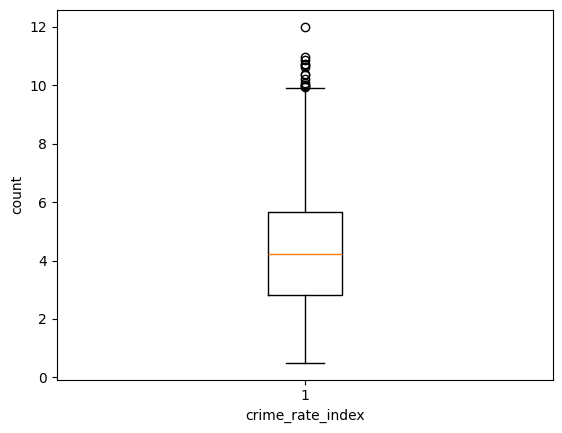

In [12]:
for col in num_cols:
    plt.boxplot(df[col])
    plt.xlabel(col)
    plt.ylabel('count')
    plt.show()

## Correlation Heatmap

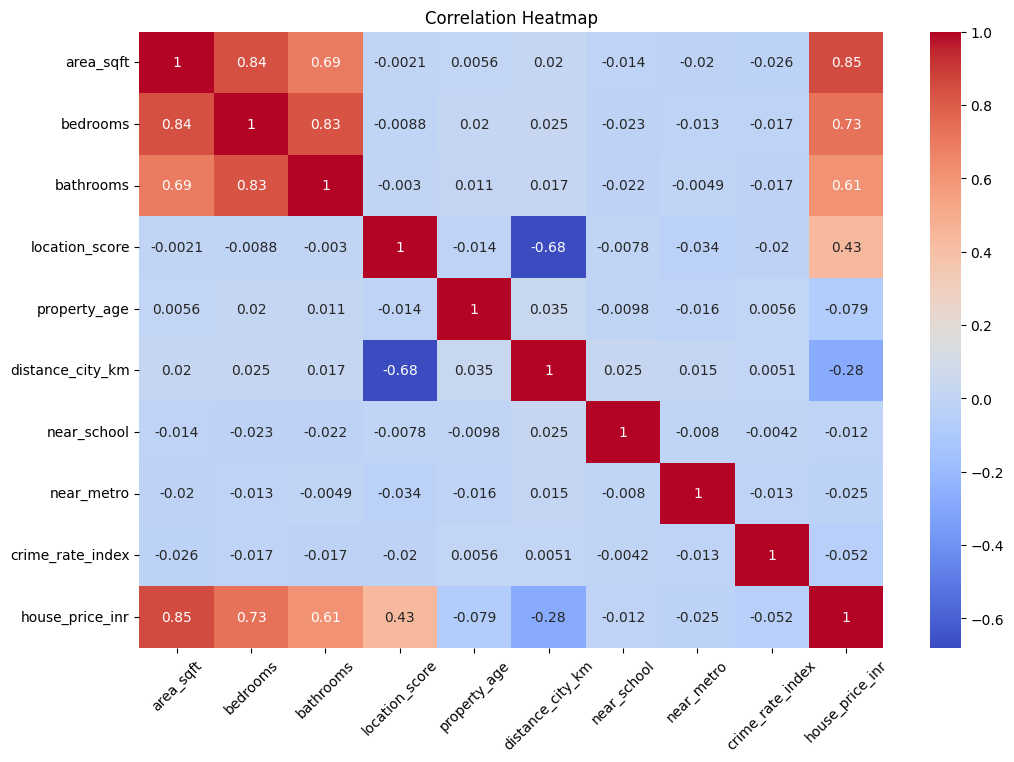

In [13]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols + [TARGET]].corr(), annot=True, cmap='coolwarm')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.title("Correlation Heatmap")
plt.show()

In [14]:
print("Top correlations with house_price_inr:")
print(df[num_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(ascending=False))

Top correlations with house_price_inr:
area_sqft           0.850342
bedrooms            0.726036
bathrooms           0.610246
location_score      0.429431
near_school        -0.012357
near_metro         -0.024632
crime_rate_index   -0.052216
property_age       -0.079124
distance_city_km   -0.281461
Name: house_price_inr, dtype: float64


## Task 7 — Train-Test Split

In [15]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3040, 9)
(760, 9)
(3040,)
(760,)


## Task 8 — Preprocessing: Feature Scaling

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Done.")
print("Mean (should be ~0):", X_train_scaled.mean(axis=0).round(4))
print("Std  (should be ~1):", X_train_scaled.std(axis=0).round(4))

Scaling Done.
Mean (should be ~0): [-0. -0.  0.  0. -0. -0. -0.  0. -0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]
